In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

import os, glob
import h5py

import sys
sys.path.append('../../')
import analysis_utils as utils
utils.load_plotting_setting()

import calc_gas_collision_spectrum as calc_gas

In [2]:
import importlib
importlib.reload(utils)
importlib.reload(calc_gas)

<module 'calc_gas_collision_spectrum' from '/Users/yuhan/work/nanospheres/gas_collisiions/analysis_notebooks/sphere_20260215_final_analysis/../../calc_gas_collision_spectrum.py'>

## Overview

This notebook shows the reconstructed spectra for the Kr, Xe, and SF6 datasets.

In [15]:
search_window_length = 2**8
time_per_search = 200e-9 * search_window_length  # s

# ── Config ────────────────────────────────────────────────────────────────
# To plot a different sphere/run, change recon_file and gas_types below.
recon_file = r'/Users/yuhan/work/nanospheres/gas_collisiions/data_processed/gas_recon/sphere_20260215_gas_recon_all.h5py'
gas_types = ['xenon', 'krypton', 'sf6', 'background']

# Stage suffixes added by recon_histograms.py (used to identify base dataset names)
_stage_suffixes = (
    '_nocal', '_cal',
    '_nocuts', '_nocuts_nocal', '_nocuts_cal',
    '_hom_bal', '_hom_bal_nocal', '_hom_bal_cal',
    '_noise', '_noise_nocal', '_noise_cal',
    '_drive', '_drive_nocal', '_drive_cal',
    '_chi2', '_chi2_nocal', '_chi2_cal',
)
# ─────────────────────────────────────────────────────────────────────────

with h5py.File(recon_file, 'r') as f:
    bins = np.arange(0, 2000, 25)
    bc   = f['recon_histograms']['bc'][:]

    # Load all histograms sorted by pressure (high → low).
    # If both 'name' and 'name_1' exist, keep only 'name_1'.
    # Each entry: (hh, hh_nocal, hh_cal, pressure_mbar)
    hhs = {}
    for gas in gas_types:
        grp = f['recon_histograms'][gas]
        # Base dataset names: exclude all stage suffixes
        datasets = [k for k in grp
                    if not any(k.endswith(s) for s in _stage_suffixes)]
        superseded = {d[:-2] for d in datasets if d.endswith('_1')}
        datasets = [d for d in datasets if d not in superseded]
        datasets.sort(key=lambda d: grp[d].attrs['pressure_mbar'], reverse=True)
        hhs[gas] = [(grp[d][:], grp[d + '_nocal'][:], grp[d + '_cal'][:],
                     grp[d].attrs['pressure_mbar']) for d in datasets]

In [16]:
hhs_bg = np.asarray([hhs['background'][i][1] for i in range(4)])
hhs_bg_wcal = np.asarray([hhs['background'][i][0] for i in range(4)])

hh_bg_avg, hh_bg_max, hh_bg_min = np.mean(hhs_bg, axis=0), np.max(hhs_bg, axis=0), np.min(hhs_bg, axis=0)
hh_bg_wcal_avg, hh_bg_wcal_max, hh_bg_wcal_min = np.mean(hhs_bg_wcal, axis=0), np.max(hhs_bg_wcal, axis=0), np.min(hhs_bg_wcal, axis=0)

## Spectra after all cuts (including calibration pulses)

Three-panel overview of Kr, Xe, and SF6 amplitude spectra across all pressure settings (high → low pressure, plasma colormap) after all quality cuts (homodyne balance, noise, drive power, chi2, double-count removal). Calibration pulses (~1100 keV/c) are **included**. The gray fill shows the average background including cal pulses (`hh_bg_wcal_avg`). Each dataset is normalised by its total event count × time per search window to give a rate in events / (25 keV/c) / s.

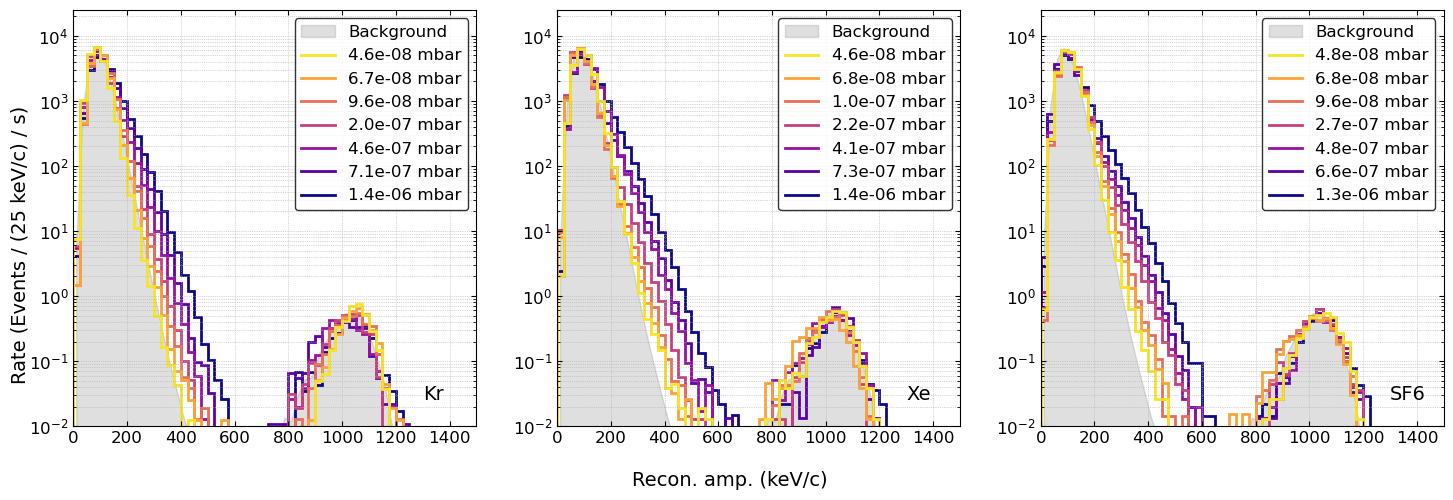

In [40]:
colors = plt.colormaps['plasma'](np.linspace(0, 0.95, 7))

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, gas, label in zip(axes, ['krypton', 'xenon', 'sf6'], ['Kr', 'Xe', 'SF6']):
    ax.fill_between(bc, 0, hh_bg_wcal_avg/(time_per_search*np.sum(hh_bg_wcal_avg)), color='gray', alpha=0.25, label='Background')

    for c, (hh, hh_nocal, hh_cal, p_mbar) in zip(colors, hhs[gas]):
        norm = time_per_search * np.sum(hh)
        ax.stairs(hh / norm, edges=bins, color=c, linewidth=2, label=f'{p_mbar:.1e} mbar')

    ax.text(1300, 2.5e-2, label, fontsize=14)
    ax.set_yscale('log')
    ax.set_xlim(0, 1500)
    ax.set_ylim(1e-2, 2.5e4)
    ax.grid(which='both', ls=':', linewidth=0.5)
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles[:1] + handles[1:][::-1], labels[:1] + labels[1:][::-1], edgecolor='k')

fig.supxlabel('Recon. amp. (keV/c)', fontsize=14)
fig.supylabel('Rate (Events / (25 keV/c) / s)', fontsize=14)
fig.tight_layout()

## Cal-pulse-removed spectra

Same three-panel layout zoomed to 0–850 keV/c, using cal-pulse-removed histograms (`hh_nocal`). Applied calibration impulses are identified by timing coincidence with the trigger and amplitude > 700 keV/c, and excluded from both the signal and background. The background shading uses the cal-removed average (`hh_bg_avg`). This is the primary view for assessing the gas collision signal: excess counts above the background are from actual gas molecule recoils.

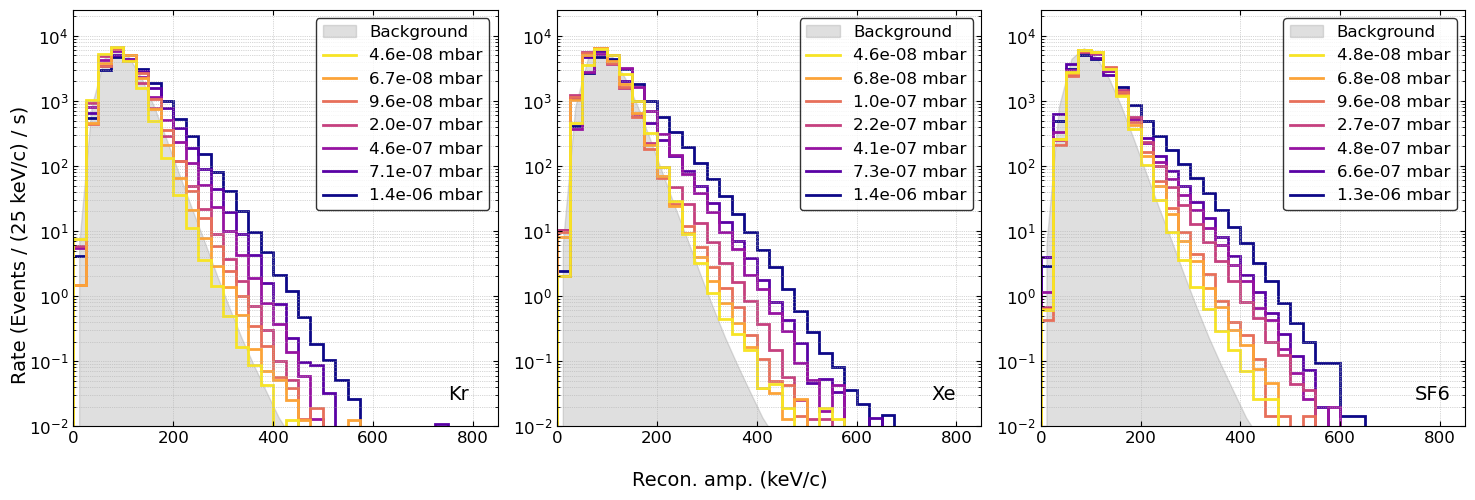

In [41]:
colors = plt.colormaps['plasma'](np.linspace(0, 0.95, 7))

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, gas, label in zip(axes, ['krypton', 'xenon', 'sf6'], ['Kr', 'Xe', 'SF6']):
    ax.fill_between(bc, 0, hh_bg_avg/(time_per_search*np.sum(hh_bg_avg)), color='gray', alpha=0.25, label='Background')

    for c, (hh, hh_nocal, hh_cal, p_mbar) in zip(colors, hhs[gas]):
        norm = time_per_search * np.sum(hh_nocal)
        ax.stairs(hh_nocal / norm, edges=bins, color=c, linewidth=2, linestyle='-', label=f'{p_mbar:.1e} mbar')

    ax.text(750, 2.5e-2, label, fontsize=14)
    ax.set_yscale('log')
    ax.set_xlim(0, 850)
    ax.set_ylim(1e-2, 2.5e4)
    ax.grid(which='both', ls=':', linewidth=0.5)
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles[:1] + handles[1:][::-1], labels[:1] + labels[1:][::-1], edgecolor='k')

fig.supxlabel('Recon. amp. (keV/c)', fontsize=14)
fig.supylabel('Rate (Events / (25 keV/c) / s)', fontsize=14)
fig.tight_layout()

## Calibration pulses only

Same layout showing only the flagged calibration pulses (`hh_cal`). The cal-pulse peak at ~1100 keV/c should be consistent across all pressures and gas species, serving as an in-situ monitor of reconstruction stability throughout the measurement campaign.

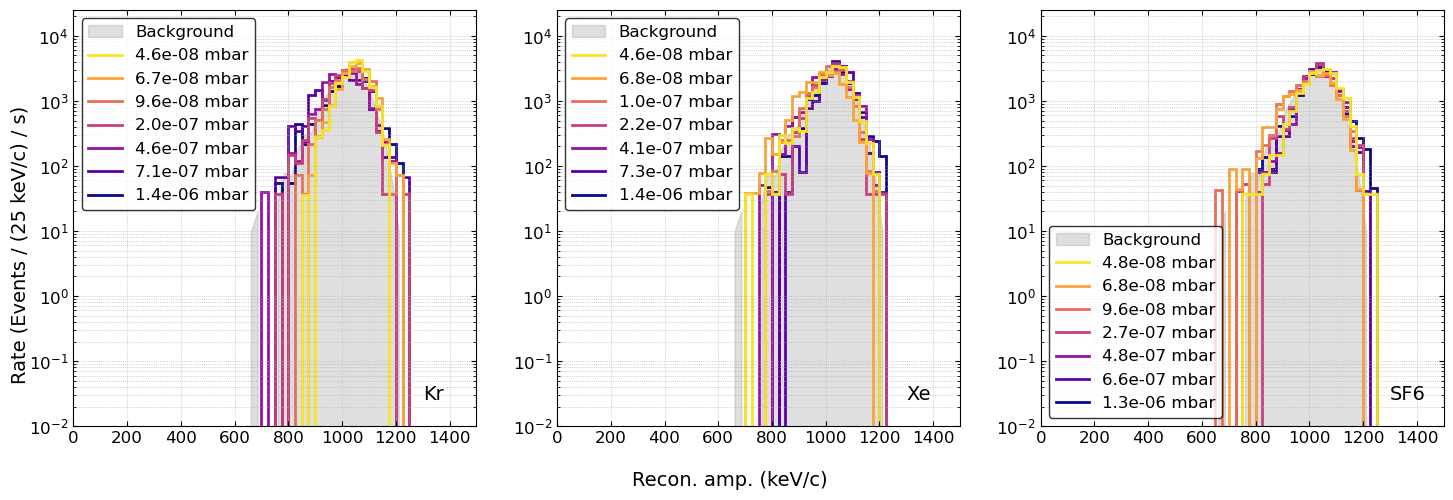

In [42]:
hhs_bg_cal = np.asarray([hhs['background'][i][2] for i in range(4)])
hh_bg_cal_avg = np.mean(hhs_bg_cal, axis=0)

colors = plt.colormaps['plasma'](np.linspace(0, 0.95, 7))

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, gas, label in zip(axes, ['krypton', 'xenon', 'sf6'], ['Kr', 'Xe', 'SF6']):
    ax.fill_between(bc, 0, hh_bg_cal_avg/(time_per_search*np.sum(hh_bg_cal_avg)), color='gray', alpha=0.25, label='Background')

    for c, (hh, hh_nocal, hh_cal, p_mbar) in zip(colors, hhs[gas]):
        if np.sum(hh_cal) == 0:
            continue
        norm = time_per_search * np.sum(hh_cal)
        ax.stairs(hh_cal / norm, edges=bins, color=c, linewidth=2, label=f'{p_mbar:.1e} mbar')

    ax.text(1300, 2.5e-2, label, fontsize=14)
    ax.set_yscale('log')
    ax.set_xlim(0, 1500)
    ax.set_ylim(1e-2, 2.5e4)
    ax.grid(which='both', ls=':', linewidth=0.5)
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles[:1] + handles[1:][::-1], labels[:1] + labels[1:][::-1], edgecolor='k')

fig.supxlabel('Recon. amp. (keV/c)', fontsize=14)
fig.supylabel('Rate (Events / (25 keV/c) / s)', fontsize=14)
fig.tight_layout()

## Species comparison at matched pressures

Each panel overlays Kr (red), Xe (green), and SF6 (blue) at approximately the same pressure level, from highest (top-left) to lowest (bottom-right). This highlights how the recoil spectrum shape differs between species at a given collision rate: heavier molecules (SF6, 146 u) transfer more momentum per collision and produce a softer spectrum shifted to higher amplitudes compared to lighter species (Kr, 84 u; Xe, 131 u). Panels where a species has no corresponding pressure are skipped. All spectra are cal-pulse-removed (`hh_nocal`) and normalised to rate.

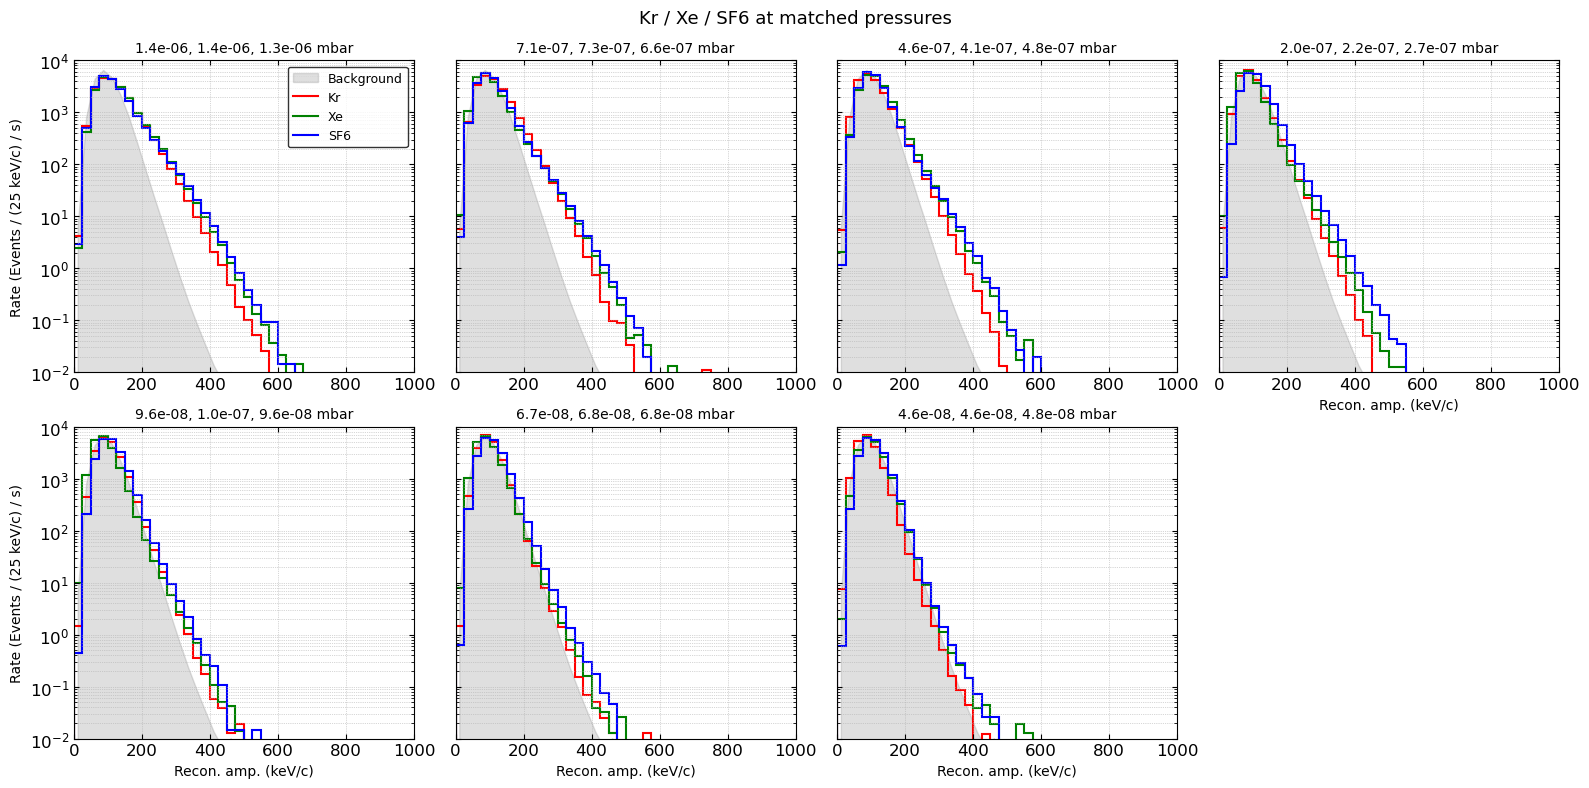

In [43]:
gas_styles = [
    ('krypton', 'Kr',  'r'),
    ('xenon',   'Xe',  'g'),
    ('sf6',     'SF6', 'b'),
]

n_pressures = max(len(hhs[gas]) for gas, _, _ in gas_styles)
ncols = 4
nrows = (n_pressures + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4 * nrows), sharey=True)
axes_flat = axes.flat

bg_norm = time_per_search * np.sum(hh_bg_avg)

for i in range(n_pressures):
    ax = axes_flat[i]
    ax.fill_between(bc, 0, hh_bg_avg / bg_norm, color='gray', alpha=0.25, label='Background')

    p_labels = []
    for gas, label, color in gas_styles:
        if i >= len(hhs[gas]):
            continue
        hh, hh_nocal, hh_cal, p_mbar = hhs[gas][i]
        norm = time_per_search * np.sum(hh_nocal)
        ax.stairs(hh_nocal / norm, edges=bins, color=color, linewidth=1.5, label=label)
        p_labels.append(f'{p_mbar:.1e}')

    ax.set_title(', '.join(p_labels) + ' mbar', fontsize=10)
    ax.set_yscale('log')
    ax.set_xlim(0, 1000)
    ax.set_ylim(1e-2, 1e4)
    ax.grid(which='both', ls=':', linewidth=0.5)
    if i % ncols == 0:
        ax.set_ylabel('Rate (Events / (25 keV/c) / s)', fontsize=10)
    if i >= n_pressures - ncols:
        ax.set_xlabel('Recon. amp. (keV/c)', fontsize=10)

# Legend on first panel; hide unused panels
axes_flat[0].legend(edgecolor='k', fontsize=9)
for ax in list(axes_flat)[n_pressures:]:
    ax.set_visible(False)

fig.suptitle('Kr / Xe / SF6 at matched pressures', fontsize=13)
fig.tight_layout()

## Xe 1e-6 mbar: effect of each data cut

Shows the Xe 1e-6 mbar spectrum at each cumulative selection stage (nocal variant) to visualise the effect of each successive cut. Stages: no cuts → homodyne balance → noise threshold → drive power → chi2 → double-count removal (final).

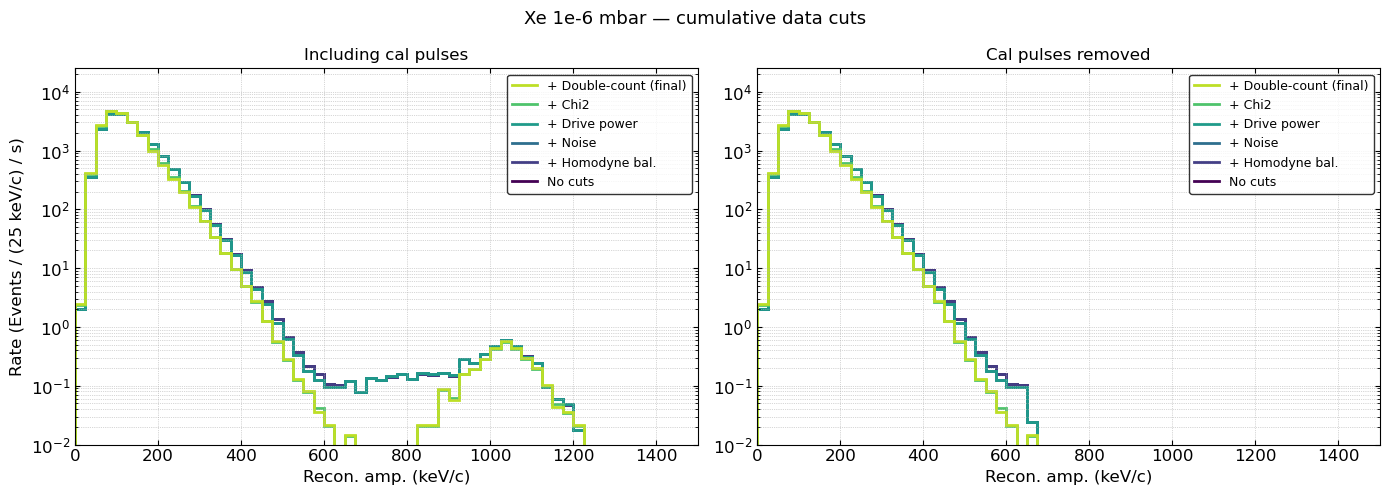

In [57]:
# Load stage-by-stage histograms for Xe 1e-6 mbar
xe_dataset = '20260219_p6e_1e-6mbar'
stages = [
    ('nocuts',  'No cuts'),
    ('hom_bal', '+ Homodyne bal.'),
    ('noise',   '+ Noise'),
    ('drive',   '+ Drive power'),
    ('chi2',    '+ Chi2'),
    ('all',     '+ Double-count (final)'),
]

with h5py.File(recon_file, 'r') as f:
    grp = f['recon_histograms']['xenon']
    xe_stages = {}
    for key, label in stages:
        if key == 'all':
            name_nocal = xe_dataset + '_nocal'
            name_total = xe_dataset
        else:
            name_nocal = f'{xe_dataset}_{key}_nocal'
            name_total = f'{xe_dataset}_{key}'
        xe_stages[key] = {
            'nocal': grp[name_nocal][:],
            'total': grp[name_total][:],
            'label': label,
        }

# Plot
colors_stage = plt.colormaps['viridis'](np.linspace(0, 0.9, len(stages)))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, variant, title in zip(axes, ['total', 'nocal'], ['Including cal pulses', 'Cal pulses removed']):
    for c, (key, label) in zip(colors_stage, stages):
        h = xe_stages[key][variant]
        norm = time_per_search * np.sum(h)
        ax.stairs(h / norm, edges=bins, color=c, linewidth=2, label=label)

    ax.set_title(title, fontsize=12)
    ax.set_yscale('log')
    ax.set_xlim(0, 1500)
    ax.set_ylim(1e-2, 2.5e4)
    ax.grid(which='both', ls=':', linewidth=0.5)
    ax.set_xlabel('Recon. amp. (keV/c)', fontsize=12)
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles[::-1], labels[::-1], edgecolor='k', fontsize=9)

axes[0].set_ylabel('Rate (Events / (25 keV/c) / s)', fontsize=12)
fig.suptitle('Xe 1e-6 mbar — cumulative data cuts', fontsize=13)
fig.tight_layout()

## Xe 1e-6 mbar: events removed by each cut

Each curve shows the events **removed** by a single cut stage, i.e. the difference between the spectrum before and after that cut. This isolates the contribution of each selection to the final spectrum.

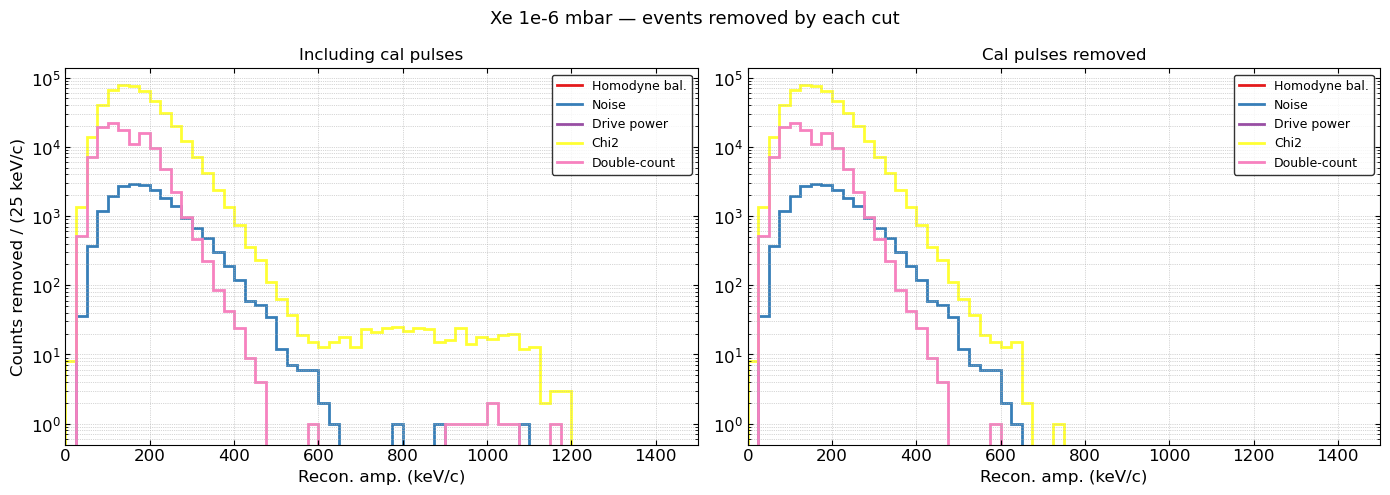

In [48]:
# Consecutive stage pairs: (before, after, label for what was removed)
cut_diffs = [
    ('nocuts',  'hom_bal', 'Homodyne bal.'),
    ('hom_bal', 'noise',   'Noise'),
    ('noise',   'drive',   'Drive power'),
    ('drive',   'chi2',    'Chi2'),
    ('chi2',    'all',     'Double-count'),
]

colors_diff = plt.colormaps['Set1'](np.linspace(0, 0.8, len(cut_diffs)))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, variant, title in zip(axes, ['total', 'nocal'], ['Including cal pulses', 'Cal pulses removed']):
    for c, (before, after, label) in zip(colors_diff, cut_diffs):
        removed = xe_stages[before][variant] - xe_stages[after][variant]
        ax.stairs(removed, edges=bins, color=c, linewidth=2, label=label)

    ax.set_title(title, fontsize=12)
    ax.set_yscale('log')
    ax.set_xlim(0, 1500)
    ax.set_ylim(0.5, None)
    ax.grid(which='both', ls=':', linewidth=0.5)
    ax.set_xlabel('Recon. amp. (keV/c)', fontsize=12)
    ax.legend(edgecolor='k', fontsize=9)

axes[0].set_ylabel('Counts removed / (25 keV/c)', fontsize=12)
fig.suptitle('Xe 1e-6 mbar — events removed by each cut', fontsize=13)
fig.tight_layout()